# Задание 8. Симуляция марковской цепи

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
bases = ['A', 'C', 'G', 'T']

P = np.array([
    [0.3312, 0.1724, 0.2347, 0.2616],
    [0.3570, 0.2496, 0.0565, 0.3369],
    [0.2942, 0.2074, 0.2507, 0.2477],
    [0.2162, 0.2022, 0.2468, 0.3347]
])

Функция генерации последовательности

In [5]:
def generate_sequence(P, length, start_state):
    seq = [start_state]
    for _ in range(length - 1):
        current = bases.index(seq[-1])
        probs = P[current] / P[current].sum()  # нормируем на всякий случай
        next_base = np.random.choice(bases, p=probs)
        seq.append(next_base)
    return ''.join(seq)

Генерация 10 последовательностей

In [6]:
sequences = [generate_sequence(P, length=1000, start_state='A') for _ in range(10)]

for i, s in enumerate(sequences):
    print(f"Seq {i+1}: {s[:50]}...")

Seq 1: ACTGTCCAACTTTCCCATACGAAAAATCAGGCCTGTGATGAACATAGAAA...
Seq 2: AATCAGATAGTTCTACAAAGTTAACTATACAATGCCTTCAGATGACCTAG...
Seq 3: AACCCAGCGAAATGCTCATCACTTTGCTTTAGAATAGCAGATGGCTGGGG...
Seq 4: ATTGGTGCAACTAGAGATCTCTGCGCTTGTTATATTTACTTTATAGAACT...
Seq 5: AATGCTCTCCACTGTTGTGTTCTCAGGGATTAAATTGGTTCTATTCTGGC...
Seq 6: AGTAAAACCGTGTGACGAAAGCCTGAAAAATGATTTTGACAGTCTGTTTT...
Seq 7: ATGTCTATTCCGAAAAGCTTGTTATGTGAATACAAGCTAACATTATAGCT...
Seq 8: ATCTATGATCACCCTGGGCACAAACTAAATCAATACTGAAAGCACAAATT...
Seq 9: AATCCAGAAAGATCTTTCATAAAAGTCGGACTATGGCAGCAGAATCAACA...
Seq 10: AAACATAATTTCTTCACAATTGTCCTAATAGTAAACAAGCGCTCTGCATG...


Подсчёт частот динуклеотидов

In [7]:
def compute_transition_matrix(seq):
    counts = np.zeros((4, 4))
    for i in range(len(seq) - 1):
        r = bases.index(seq[i])
        c = bases.index(seq[i+1])
        counts[r, c] += 1
    row_sums = counts.sum(axis=1, keepdims=True)
    return counts / np.where(row_sums > 0, row_sums, 1)

matrices = [compute_transition_matrix(s) for s in sequences]
P_empirical = np.mean(matrices, axis=0)

print("Средняя эмпирическая матрица:")
print(pd.DataFrame(P_empirical, index=bases, columns=bases).round(4))

Средняя эмпирическая матрица:
        A       C       G       T
A  0.3267  0.1797  0.2213  0.2723
C  0.3493  0.2455  0.0547  0.3505
G  0.2941  0.2246  0.2436  0.2377
T  0.2230  0.2017  0.2561  0.3191


Сравнение матриц — тепловые карты

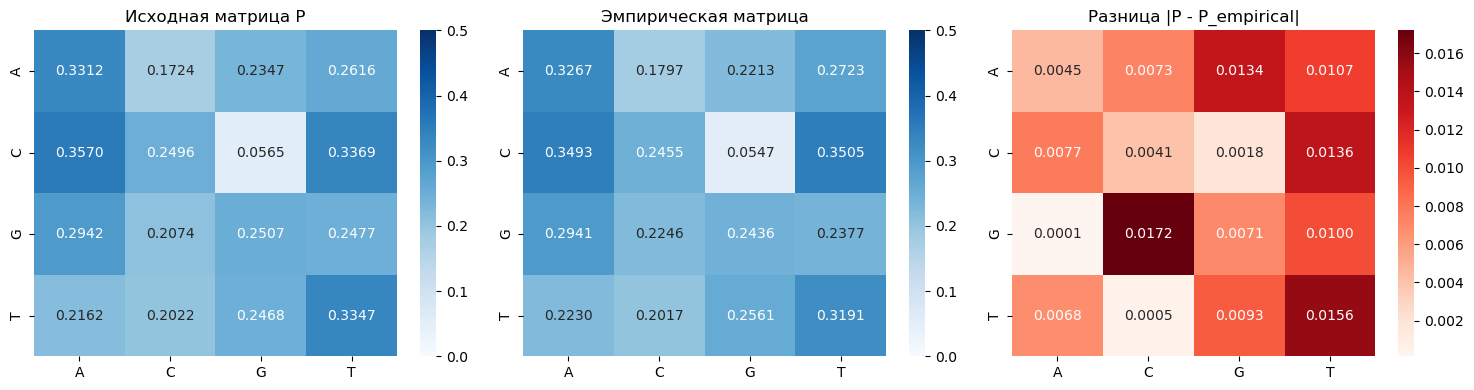

Средняя абсолютная разница: 0.0081
Максимальная разница: 0.0172


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.heatmap(P, annot=True, fmt='.4f', xticklabels=bases, yticklabels=bases,
            cmap='Blues', ax=axes[0], vmin=0, vmax=0.5)
axes[0].set_title('Исходная матрица P')

sns.heatmap(P_empirical, annot=True, fmt='.4f', xticklabels=bases, yticklabels=bases,
            cmap='Blues', ax=axes[1], vmin=0, vmax=0.5)
axes[1].set_title('Эмпирическая матрица')

diff = np.abs(P - P_empirical)
sns.heatmap(diff, annot=True, fmt='.4f', xticklabels=bases, yticklabels=bases,
            cmap='Reds', ax=axes[2])
axes[2].set_title('Разница |P - P_empirical|')

plt.tight_layout()
plt.show()

print(f"Средняя абсолютная разница: {diff.mean():.4f}")
print(f"Максимальная разница: {diff.max():.4f}")